In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import entropy
from matplotlib.animation import FuncAnimation
import seaborn as sns
from scipy.stats import wilcoxon

In [12]:
data = pd.read_csv('/Users/34633/Documents/master/tfm/data/chinadata/user.csv', sep =',', encoding = 'latin1')
data.head()

,user_id,gender,grade
0,219,1,4
1,220,1,4
2,280,0,3
3,430,1,5
4,291,1,3


In [13]:
new_data = data.copy()

user_gender_info = new_data.drop_duplicates('user_id')[['user_id', 'gender']]
unique_users = user_gender_info['user_id'].values
original_genders = user_gender_info['gender'].values

shuffled_genders = np.random.permutation(original_genders)
user_gender_map = dict(zip(unique_users, shuffled_genders))

new_data['gender'] = new_data['user_id'].map(user_gender_map)
new_data.to_csv('data_shuffled_gender.csv', index=False)
new_data.head()

,user_id,gender,grade
0,219,0,4
1,220,0,4
2,280,1,3
3,430,1,5
4,291,0,3


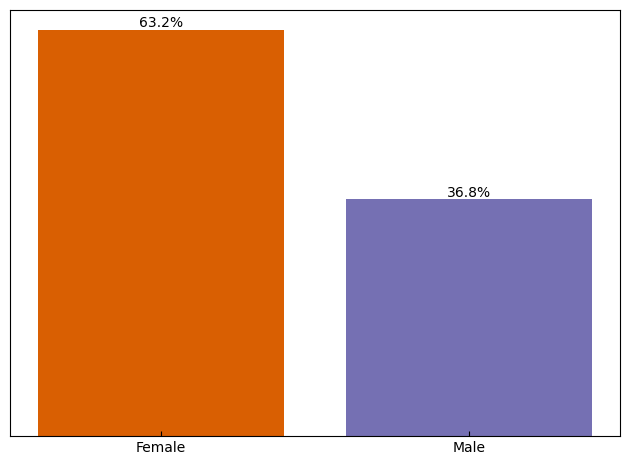

In [14]:
gender_map = {0: 'Male', 1: 'Female'}
new_data['gender_label'] = new_data['gender'].map(gender_map)
cmap = plt.get_cmap('Dark2')
selected_indices = [1,2]
colors = [cmap(i) for i in selected_indices]
count = new_data['gender_label'].value_counts().sort_values(ascending=False)
total = count.sum()

fig, ax = plt.subplots()
bars = ax.bar(count.index, count.values, color=colors)
ax.set_ylabel('Count')
ax.yaxis.set_visible(False)

for bar in bars:
    height = bar.get_height()
    percentage = (height / total) * 100
    ax.text(bar.get_x() + bar.get_width() / 2, height, f'{percentage:.1f}%', ha='center', va='bottom')

plt.xticks(rotation=0)
plt.tight_layout()
plt.tick_params(axis='both', direction='in')
#plt.savefig('gender.png')

In [15]:
checkins = pd.read_csv('/Users/34633/Documents/master/tfm/data/chinadata/checkIns.csv', sep =',', encoding = 'latin1')
checkins = checkins.merge(new_data[['user_id', 'gender']], on='user_id', how='left')
checkins.columns.tolist()

['user_id',
 'day',
 'day_of_week',
 'time',
 'latitude',
 'longitude',
 'POI_id',
 'POI_category',
 'mood',
 'gender']

In [16]:
checkins = pd.read_csv('/Users/34633/Documents/master/tfm/data/chinadata/checkIns.csv', sep =',', encoding = 'latin1')
checkins = checkins.merge(data[['user_id', 'gender']], on='user_id', how='left')
checkins.columns.tolist()

['user_id',
 'day',
 'day_of_week',
 'time',
 'latitude',
 'longitude',
 'POI_id',
 'POI_category',
 'mood',
 'gender']

In [17]:
def compute_hu(seq):
    if len(seq) == 0: return 0
    probs = pd.Series(seq).value_counts(normalize=True)
    return -np.sum(probs * np.log2(probs))

def find_shortest_new_sequence(sequence, i):
    n = len(sequence)
    for length in range(1, n - i + 1):
        sub_sequence = sequence[i:i + length]
        is_seen = False
        for j in range(i):
            if sequence[j:j + length] == sub_sequence:
                is_seen = True
                break
        if not is_seen:
            return length
    return n - i + 1

def compute_hc(sequence):
    n = len(sequence)
    if n < 2:
        return np.nan
    total_lambda = 0
    for i in range(n):
        total_lambda += find_shortest_new_sequence(sequence, i)
    return (n * np.log2(n)) / total_lambda

user_stats = checkins.groupby('user_id').agg({'POI_id': lambda x: compute_hu(list(x)),'gender': 'first'}).rename(columns={'POI_id': 'Hu'})


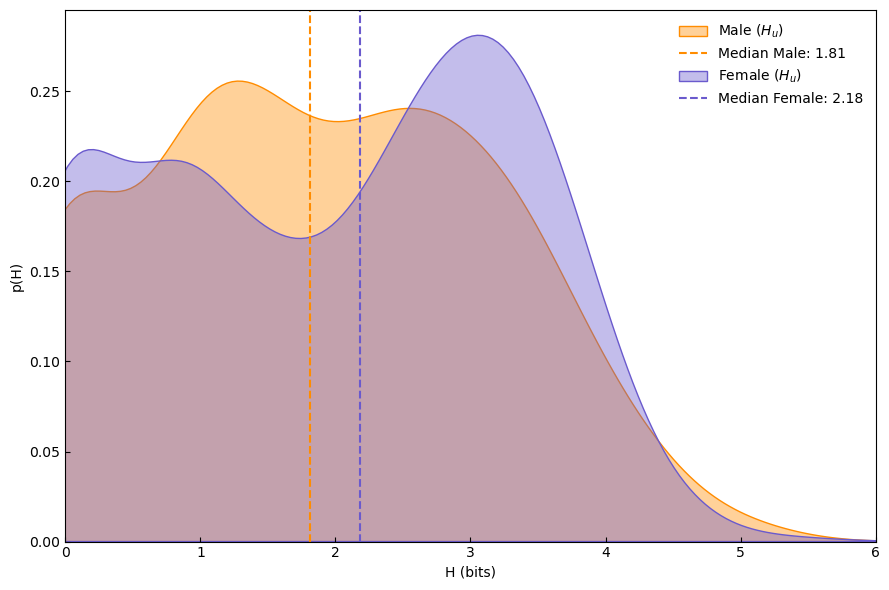

-0.3726208043028545


In [22]:
checkins['time'] = pd.to_datetime(checkins['time'])
checkins['mov_day'] = (checkins['time'] - pd.Timedelta(hours=4)).dt.date
entropy_by_user = checkins.groupby(['user_id', 'mov_day']).agg({'POI_id': lambda x: compute_hu(list(x)),'gender': 'first'  }).rename(columns={'POI_id': 'Hu'})
hu_male = entropy_by_user[entropy_by_user['gender'] == 0]['Hu']
hu_female = entropy_by_user[entropy_by_user['gender'] == 1]['Hu']

plt.figure(figsize=(9, 6))
sns.kdeplot(hu_male, fill=True, color='darkorange', label='Male ($H_u$)', alpha=0.4)
plt.axvline(hu_male.median(), color='darkorange', linestyle='--', label=f'Median Male: {hu_male.median():.2f}')
sns.kdeplot(hu_female, fill=True, color='slateblue', label='Female ($H_u$)', alpha=0.4)
plt.axvline(hu_female.median(), color='slateblue', linestyle='--',  label=f'Median Female: {hu_female.median():.2f}')
plt.xlabel('H (bits)')
plt.ylabel('p(H)')
plt.legend(frameon=False)
plt.tick_params(axis='both', direction='in')
plt.xlim(0, 6)
plt.tight_layout()
#plt.savefig('figs/unc.png')
plt.show()

entropy_dif= hu_male.median()-hu_female.median()
print(entropy_dif)

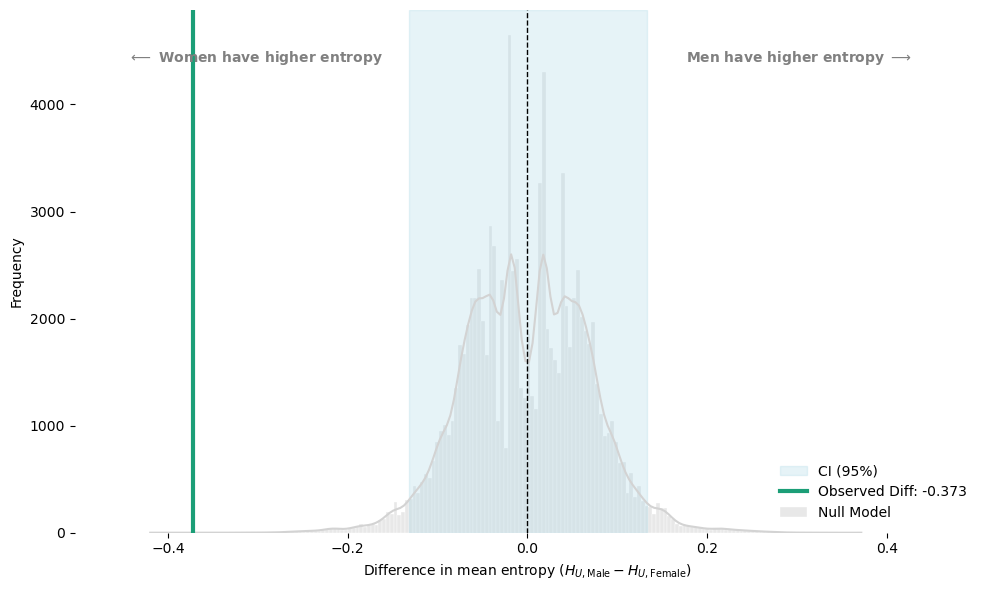

p-value: 0.0000


In [19]:
obs_diff_hu = entropy_dif
hu_values = user_stats['Hu'].values
n_users = len(hu_values)
null_diffs = []
for _ in range(100000):
    shuffled_genders = np.random.choice([0, 1], size=n_users)
    m_med = np.median(hu_values[shuffled_genders == 0])
    f_med = np.median(hu_values[shuffled_genders == 1])
    null_diffs.append(m_med - f_med)

null_diffs = np.array(null_diffs)

ci_low = np.percentile(null_diffs, 2.5)
ci_high = np.percentile(null_diffs, 97.5)

cmap = plt.get_cmap('Dark2')

plt.figure(figsize=(10, 6))
sns.histplot(null_diffs, kde=True, color='lightgray', edgecolor='white', label='Null Model')
plt.axvspan(ci_low, ci_high, color='lightblue', alpha=0.3, label='CI (95%)')
plt.axvline(obs_diff_hu, color=cmap(0), lw=3, label=f'Observed Diff: {obs_diff_hu:.3f}')
plt.axvline(0, color='black', lw=1, linestyle='--')

y_limit = plt.gca().get_ylim()[1]
x_limit = max(abs(null_diffs.min()), abs(null_diffs.max()), abs(obs_diff_hu)) * 1.2

plt.text(-x_limit*0.6, y_limit*0.9, '$\longleftarrow$ Women have higher entropy', color='gray', fontweight='bold', ha='center')
plt.text(x_limit*0.6, y_limit*0.9, 'Men have higher entropy $\longrightarrow$', color='gray', fontweight='bold', ha='center')

plt.xlim(-x_limit, x_limit)
plt.xlabel(r'Difference in mean entropy ($H_{U, \mathrm{Male}} - H_{U, \mathrm{Female}}$)')
plt.ylabel('Frequency')
plt.legend(frameon=False)

for spine in plt.gca().spines.values():
    spine.set_visible(False)

plt.tight_layout()
#plt.savefig('figs/null_modelunc.png', dpi=300)
plt.show()

p_val = np.mean(np.abs(null_diffs) >= np.abs(obs_diff_hu))
print(f"p-value: {p_val:.4f}")

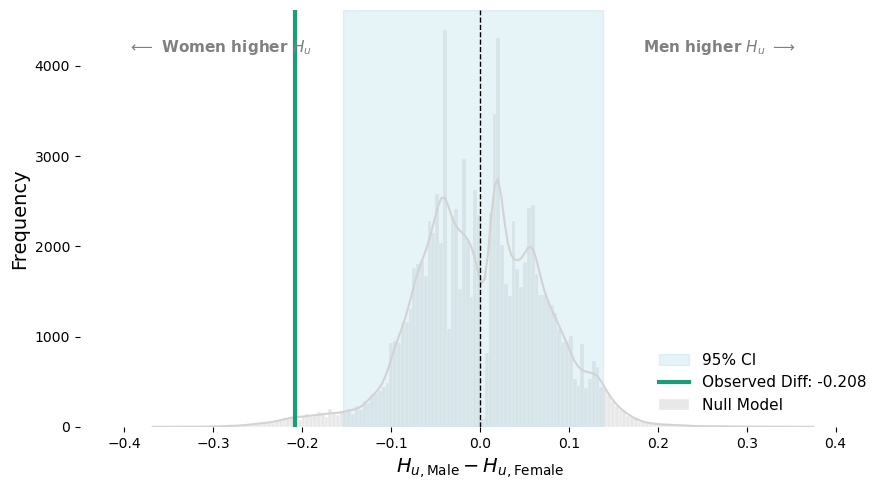

p-value: 0.0109


In [20]:
original_genders = user_stats['gender'].values
hu_values = user_stats['Hu'].values
n_users = len(hu_values)

#obs_diff_hu = -0.23 
obs_diff_hu = -0.20762942086709968
null_diffs = []
for _ in range(100000):
    shuffled_genders = np.random.permutation(original_genders)
    m_med = np.median(hu_values[shuffled_genders == 0])
    f_med = np.median(hu_values[shuffled_genders == 1])
    null_diffs.append(m_med - f_med)
null_diffs = np.array(null_diffs)

ci_low = np.percentile(null_diffs, 2.5)
ci_high = np.percentile(null_diffs, 97.5)
p_val = np.mean(np.abs(null_diffs) >= np.abs(obs_diff_hu))

cmap = plt.get_cmap('Dark2')
plt.figure(figsize=(9,5))
sns.histplot(null_diffs, kde=True, color='lightgray', edgecolor='white', label='Null Model')
plt.axvspan(ci_low, ci_high, color='lightblue', alpha=0.3, label='95% CI')
plt.axvline(obs_diff_hu, color=cmap(0), lw=3, label=f'Observed Diff: {obs_diff_hu:.3f}')
plt.axvline(0, color='black', lw=1, linestyle='--')
y_limit = plt.gca().get_ylim()[1]
x_limit = max(abs(null_diffs.min()), abs(null_diffs.max()), abs(obs_diff_hu)) * 1.2
plt.text(-x_limit*0.65, y_limit*0.9, '$\longleftarrow$ Women higher $H_u$', color='gray', fontweight='bold', ha='center', fontsize=11)
plt.text(x_limit*0.6, y_limit*0.9, 'Men higher $H_u$ $\longrightarrow$', color='gray', fontweight='bold', ha='center', fontsize=11)
plt.xlim(-x_limit, x_limit)
plt.xlabel(r'$H_{u, \mathrm{Male}} - H_{u, \mathrm{Female}}$', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
plt.legend(frameon=False, fontsize=11)
for spine in plt.gca().spines.values():
    spine.set_visible(False)
plt.tight_layout()
#plt.savefig('figs/null_model_hu_final.png', dpi=300)
plt.show()
print(f"p-value: {p_val:.4f}")

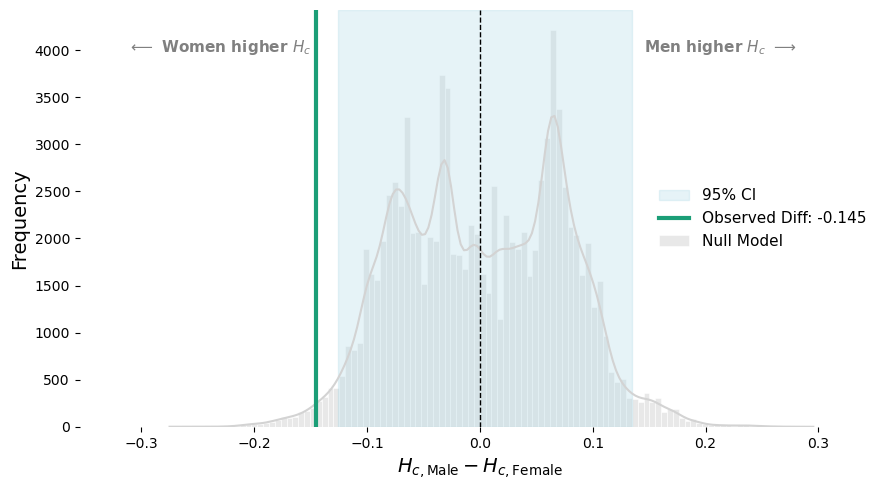

p-value (Hc): 0.03077


In [21]:
user_stats = checkins.groupby('user_id').agg({'POI_id': [lambda x: compute_hu(list(x)), lambda x: compute_hc(list(x))],'gender': 'first'})

user_stats.columns = ['Hu', 'Hc', 'gender']
user_stats = user_stats.dropna()
original_genders = user_stats['gender'].values
hc_values = user_stats['Hc'].values
n_users = len(hc_values)
#obs_diff_hc = -0.18 
obs_diff_hc = -0.1452232917105456
null_diffs_hc = []
for _ in range(100000):
    shuffled_genders = np.random.permutation(original_genders)
    m_med = np.median(hc_values[shuffled_genders == 0])
    f_med = np.median(hc_values[shuffled_genders == 1])
    null_diffs_hc.append(m_med - f_med)
null_diffs_hc = np.array(null_diffs_hc)

ci_low = np.percentile(null_diffs_hc, 2.5)
ci_high = np.percentile(null_diffs_hc, 97.5)
p_val = np.mean(np.abs(null_diffs_hc) >= np.abs(obs_diff_hc))
cmap = plt.get_cmap('Dark2')
plt.figure(figsize=(9,5))
sns.histplot(null_diffs_hc, kde=True, color='lightgray', edgecolor='white', label='Null Model')
plt.axvspan(ci_low, ci_high, color='lightblue', alpha=0.3, label='95% CI')
plt.axvline(obs_diff_hc, color=cmap(0), lw=3, label=f'Observed Diff: {obs_diff_hc:.3f}')
plt.axvline(0, color='black', lw=1, linestyle='--')
y_max = plt.gca().get_ylim()[1]
x_range = max(abs(null_diffs_hc.min()), abs(null_diffs_hc.max()), abs(obs_diff_hc)) * 1.2
plt.text(-x_range*0.65, y_max*0.9, '$\longleftarrow$ Women higher $H_c$', color='gray', fontweight='bold', ha='center', fontsize=11)
plt.text(x_range*0.6, y_max*0.9, 'Men higher $H_c$ $\longrightarrow$', color='gray', fontweight='bold', ha='center', fontsize=11)
plt.xlim(-x_range, x_range)
plt.xlabel(r'$H_{c, \mathrm{Male}} - H_{c, \mathrm{Female}}$', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
plt.legend(frameon=False, loc='best', fontsize=11)

for spine in plt.gca().spines.values():
    spine.set_visible(False)

plt.tight_layout()
#plt.savefig('figs/null_model_hc_final.png', dpi=300)
plt.show()

print(f"p-value (Hc): {p_val:.5f}")

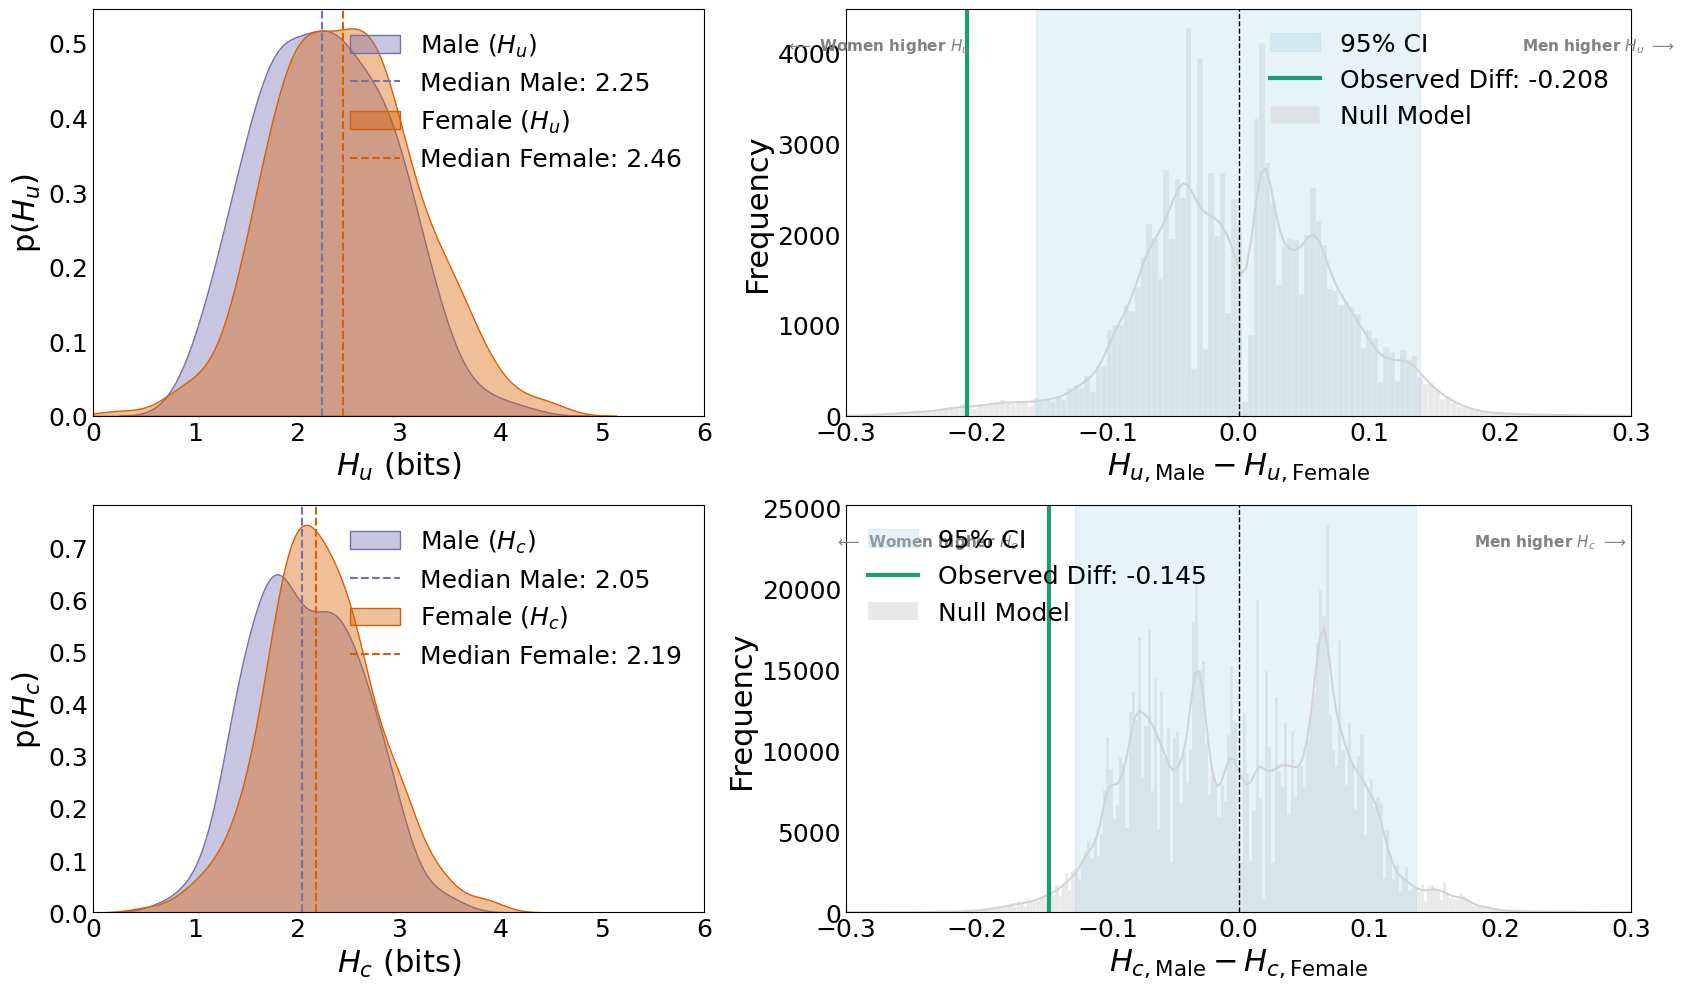

 Hu (F - M): 0.2076
 Hc (F - M): 0.1452
p-value (Hu): 0.0108
p-value (Hc): 0.03143


In [23]:
daily_entropy = checkins.groupby(['user_id', 'mov_day', 'gender'])['POI_id'].apply(list).reset_index()
daily_entropy = daily_entropy[daily_entropy['POI_id'].apply(lambda x: len(set(x)) > 1)]
daily_entropy['Hu_val'] = daily_entropy['POI_id'].apply(compute_hu)
user_entropy_final = daily_entropy.groupby(['user_id', 'gender'])['Hu_val'].mean().reset_index()
hu_male = user_entropy_final[user_entropy_final['gender'] == 0]['Hu_val']
hu_female = user_entropy_final[user_entropy_final['gender'] == 1]['Hu_val']

daily_hc = checkins.groupby(['user_id', 'mov_day', 'gender'])['POI_id'].apply(list).reset_index()
daily_hc = daily_hc[daily_hc['POI_id'].apply(lambda x: len(set(x)) > 1)]
daily_hc['Hc_val'] = daily_hc['POI_id'].apply(compute_hc)
user_hc_final = daily_hc.groupby(['user_id', 'gender'])['Hc_val'].mean().reset_index()
hc_male = user_hc_final[user_hc_final['gender'] == 0]['Hc_val']
hc_female = user_hc_final[user_hc_final['gender'] == 1]['Hc_val']

user_stats = checkins.groupby('user_id').agg({'POI_id': [lambda x: compute_hu(list(x)), lambda x: compute_hc(list(x))], 'gender': 'first'})
user_stats.columns = ['Hu', 'Hc', 'gender']
user_stats = user_stats.dropna()
original_genders = user_stats['gender'].values
hu_values = user_stats['Hu'].values
hc_values = user_stats['Hc'].values

obs_diff_hu = -0.20762942086709968
null_diffs_hu = []
for _ in range(100000):
    shuffled_genders = np.random.permutation(original_genders)
    m_med = np.median(hu_values[shuffled_genders == 0])
    f_med = np.median(hu_values[shuffled_genders == 1])
    null_diffs_hu.append(m_med - f_med)
null_diffs_hu = np.array(null_diffs_hu)
p_val_hu = np.mean(np.abs(null_diffs_hu) >= np.abs(obs_diff_hu))

obs_diff_hc = -0.1452232917105456
null_diffs_hc = []
for _ in range(1000000):
    shuffled_genders = np.random.permutation(original_genders)
    m_med = np.median(hc_values[shuffled_genders == 0])
    f_med = np.median(hc_values[shuffled_genders == 1])
    null_diffs_hc.append(m_med - f_med)
null_diffs_hc = np.array(null_diffs_hc)
p_val_hc = np.mean(np.abs(null_diffs_hc) >= np.abs(obs_diff_hc))


cmap = plt.get_cmap('Dark2')
colors = [cmap(i) for i in [1, 2]]

fig, axs = plt.subplots(2, 2, figsize=(17, 10), gridspec_kw={'width_ratios': [7, 9]})

sns.kdeplot(hu_male, fill=True, color=colors[1], label='Male ($H_u$)', alpha=0.4, ax=axs[0, 0])
axs[0, 0].axvline(hu_male.median(), color=colors[1], linestyle='--', label=f'Median Male: {hu_male.median():.2f}')
sns.kdeplot(hu_female, fill=True, color=colors[0], label='Female ($H_u$)', alpha=0.4, ax=axs[0, 0])
axs[0, 0].axvline(hu_female.median(), color=colors[0], linestyle='--', label=f'Median Female: {hu_female.median():.2f}')
axs[0, 0].set_xlabel('$H_u$ (bits)', fontsize=22)
axs[0, 0].set_ylabel('p($H_u$)', fontsize=22)
axs[0, 0].legend(frameon=False, fontsize=18, loc='upper right')
axs[0, 0].tick_params(axis='both', direction='in', length=0, labelsize=18)
axs[0, 0].set_xlim(0, 6)

ci_low_hu = np.percentile(null_diffs_hu, 2.5)
ci_high_hu = np.percentile(null_diffs_hu, 97.5)
sns.histplot(null_diffs_hu, kde=True, color='lightgray', edgecolor='white', label='Null Model', ax=axs[0, 1])
axs[0, 1].axvspan(ci_low_hu, ci_high_hu, color='lightblue', alpha=0.3, label='95% CI')
axs[0, 1].axvline(obs_diff_hu, color=cmap(0), lw=3, label=f'Observed Diff: {obs_diff_hu:.3f}')
axs[0, 1].axvline(0, color='black', lw=1, linestyle='--')
y_limit_hu = axs[0, 1].get_ylim()[1]
x_limit_hu = max(abs(null_diffs_hu.min()), abs(null_diffs_hu.max()), abs(obs_diff_hu)) * 1.2
axs[0, 1].text(-x_limit_hu*0.6, y_limit_hu*0.9, '$\longleftarrow$ Women higher $H_u$', color='gray', fontweight='bold', ha='center', fontsize=11)
axs[0, 1].text(x_limit_hu*0.6, y_limit_hu*0.9, 'Men higher $H_u$ $\longrightarrow$', color='gray', fontweight='bold', ha='center', fontsize=11)
axs[0, 1].set_xlim(-0.3,0.3)
axs[0, 1].set_xlabel(r'$H_{u, \mathrm{Male}} - H_{u, \mathrm{Female}}$', fontsize=22)
axs[0, 1].set_ylabel('Frequency', fontsize=22)
axs[0, 1].tick_params(axis='both', direction='in', length=0, labelsize=18)
axs[0, 1].legend(frameon=False, fontsize=18)

sns.kdeplot(hc_male, fill=True, color=colors[1], label='Male ($H_c$)', alpha=0.4, ax=axs[1, 0])
axs[1, 0].axvline(hc_male.median(), color=colors[1], linestyle='--', label=f'Median Male: {hc_male.median():.2f}')
sns.kdeplot(hc_female, fill=True, color=colors[0], label='Female ($H_c$)', alpha=0.4, ax=axs[1, 0])
axs[1, 0].axvline(hc_female.median(), color=colors[0], linestyle='--', label=f'Median Female: {hc_female.median():.2f}')
axs[1, 0].set_xlabel('$H_c$ (bits)', fontsize=22)
axs[1, 0].set_ylabel('p($H_c$)', fontsize=22)
axs[1, 0].legend(frameon=False, fontsize=18)
axs[1, 0].tick_params(axis='both', direction='in', length=0, labelsize=18)
axs[1, 0].set_xlim(0, 6)

ci_low_hc = np.percentile(null_diffs_hc, 2.5)
ci_high_hc = np.percentile(null_diffs_hc, 97.5)
sns.histplot(null_diffs_hc, kde=True, color='lightgray', edgecolor='white', label='Null Model', ax=axs[1, 1])
axs[1, 1].axvspan(ci_low_hc, ci_high_hc, color='lightblue', alpha=0.3, label='95% CI')
axs[1, 1].axvline(obs_diff_hc, color=cmap(0), lw=3, label=f'Observed Diff: {obs_diff_hc:.3f}')
axs[1, 1].axvline(0, color='black', lw=1, linestyle='--')
y_max_hc = axs[1, 1].get_ylim()[1]
x_range_hc = max(abs(null_diffs_hc.min()), abs(null_diffs_hc.max()), abs(obs_diff_hc)) * 1.2
axs[1, 1].text(-x_range_hc*0.6, y_max_hc*0.9, '$\longleftarrow$ Women higher $H_c$', color='gray', fontweight='bold', ha='center', fontsize=11)
axs[1, 1].text(x_range_hc*0.6, y_max_hc*0.9, 'Men higher $H_c$ $\longrightarrow$', color='gray', fontweight='bold', ha='center', fontsize=11)
axs[1, 1].set_xlim(-0.3,0.3)
axs[1, 1].set_xlabel(r'$H_{c, \mathrm{Male}} - H_{c, \mathrm{Female}}$', fontsize=22)
axs[1, 1].set_ylabel('Frequency', fontsize=22)
axs[1, 1].tick_params(axis='both', direction='in', length=0, labelsize=18)
axs[1, 1].legend(frameon=False, loc='best', fontsize=18)


plt.tight_layout()
#plt.savefig('figs/panel_entropy_analysis.png', dpi=300)
plt.show()


print(f" Hu (F - M): {hu_female.median() - hu_male.median():.4f}")
print(f" Hc (F - M): {hc_female.median() - hc_male.median():.4f}")
print(f"p-value (Hu): {p_val_hu:.4f}")
print(f"p-value (Hc): {p_val_hc:.5f}")

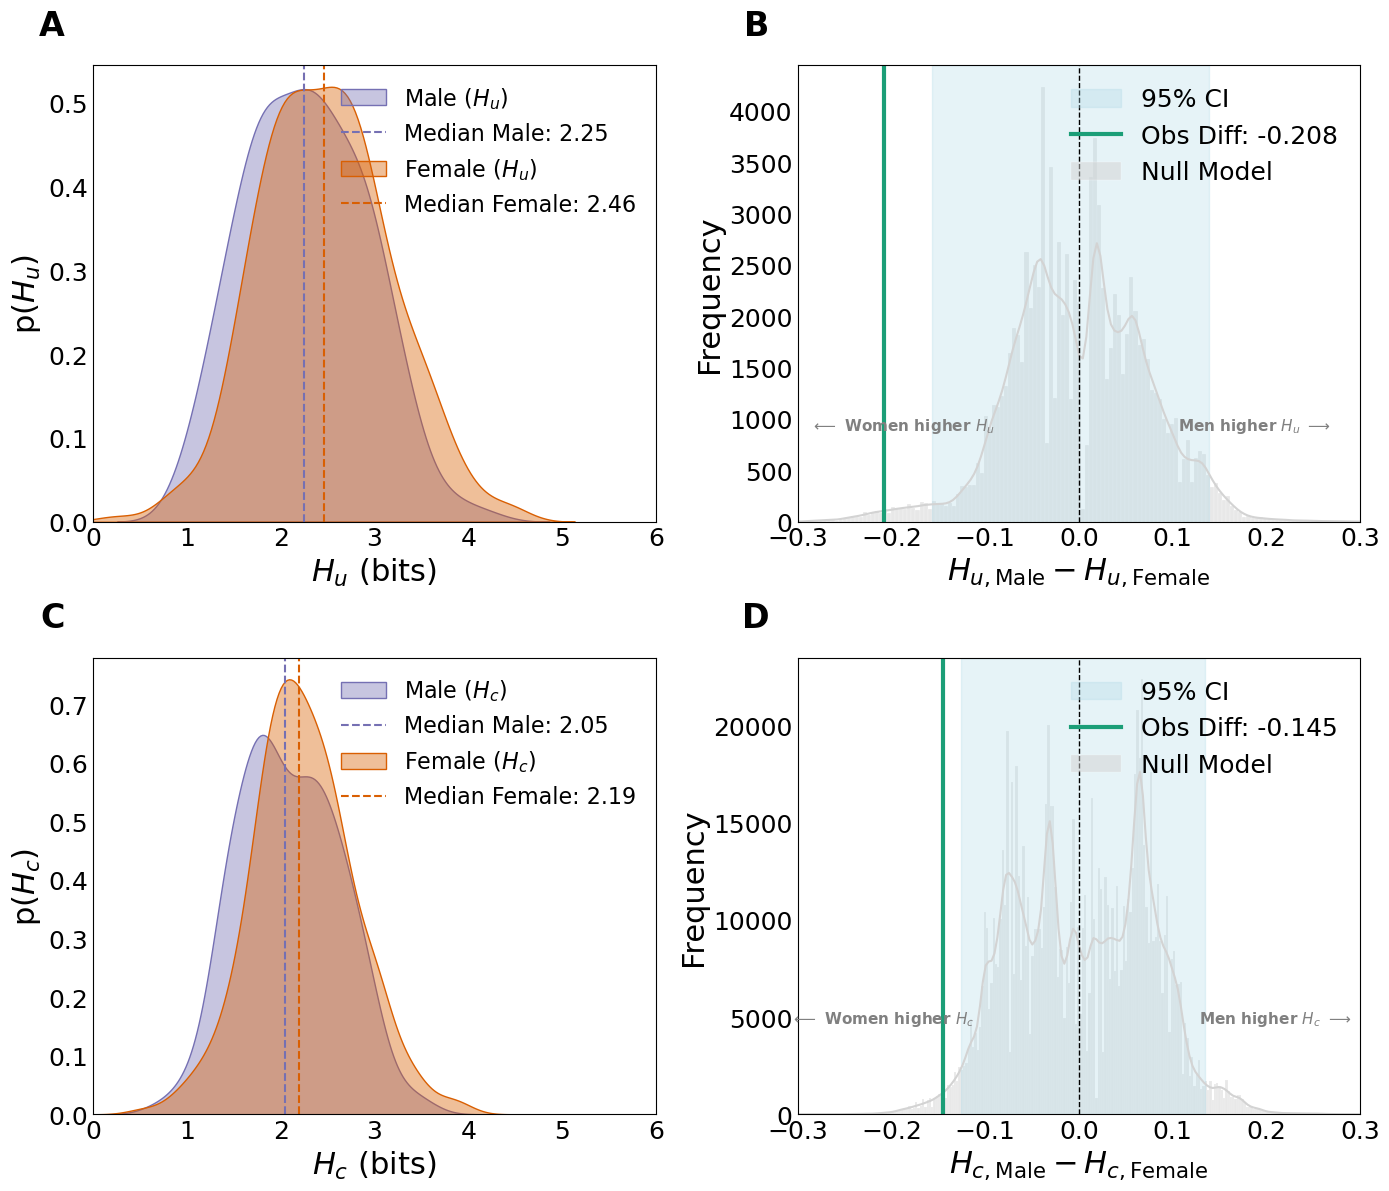

Diferencia Medianas Hu (F - M): 0.2076
Diferencia Medianas Hc (F - M): 0.1452
p-value (Hu): 0.0109
p-value (Hc): 0.03139


In [ ]:
cmap = plt.get_cmap('Dark2')
colors = [cmap(i) for i in [1, 2]]
fig, axs = plt.subplots(2, 2, figsize=(14, 12), gridspec_kw={'width_ratios': [7, 7]})
label_opts = dict(x=-0.05, y=1.05, fontsize=24, fontweight='bold', va='bottom', ha='right')

sns.kdeplot(hu_male, fill=True, color=colors[1], label='Male ($H_u$)', alpha=0.4, ax=axs[0, 0])
axs[0, 0].axvline(hu_male.median(), color=colors[1], linestyle='--', label=f'Median Male: {hu_male.median():.2f}')
sns.kdeplot(hu_female, fill=True, color=colors[0], label='Female ($H_u$)', alpha=0.4, ax=axs[0, 0])
axs[0, 0].axvline(hu_female.median(), color=colors[0], linestyle='--', label=f'Median Female: {hu_female.median():.2f}')
axs[0, 0].set_xlabel('$H_u$ (bits)', fontsize=22)
axs[0, 0].set_ylabel('p($H_u$)', fontsize=22)
axs[0, 0].legend(frameon=False, fontsize=16, loc='upper right')
axs[0, 0].tick_params(axis='both', direction='in', length=0, labelsize=18)
axs[0, 0].set_xlim(0, 6)
axs[0, 0].text(transform=axs[0, 0].transAxes, s="A", **label_opts)

ci_low_hu = np.percentile(null_diffs_hu, 2.5)
ci_high_hu = np.percentile(null_diffs_hu, 97.5)
sns.histplot(null_diffs_hu, kde=True, color='lightgray', edgecolor='white', label='Null Model', ax=axs[0, 1])
axs[0, 1].axvspan(ci_low_hu, ci_high_hu, color='lightblue', alpha=0.3, label='95% CI')
axs[0, 1].axvline(obs_diff_hu, color=cmap(0), lw=3, label=f'Obs Diff: {obs_diff_hu:.3f}')
axs[0, 1].axvline(0, color='black', lw=1, linestyle='--')
y_limit_hu = axs[0, 1].get_ylim()[1]
x_limit_hu = max(abs(null_diffs_hu.min()), abs(null_diffs_hu.max()), abs(obs_diff_hu)) * 1.2
axs[0, 1].text(-x_limit_hu*0.4, y_limit_hu*0.2, '$\longleftarrow$ Women higher $H_u$', color='gray', fontweight='bold', ha='center', fontsize=11)
axs[0, 1].text(x_limit_hu*0.4, y_limit_hu*0.2, 'Men higher $H_u$ $\longrightarrow$', color='gray', fontweight='bold', ha='center', fontsize=11)
axs[0, 1].set_xlim(-0.3, 0.3)
axs[0, 1].set_xlabel(r'$H_{u, \mathrm{Male}} - H_{u, \mathrm{Female}}$', fontsize=22)
axs[0, 1].set_ylabel('Frequency', fontsize=22)
axs[0, 1].tick_params(axis='both', direction='in', length=0, labelsize=18)
axs[0, 1].legend(frameon=False, fontsize=18)
axs[0, 1].text(transform=axs[0, 1].transAxes, s="B", **label_opts)

sns.kdeplot(hc_male, fill=True, color=colors[1], label='Male ($H_c$)', alpha=0.4, ax=axs[1, 0])
axs[1, 0].axvline(hc_male.median(), color=colors[1], linestyle='--', label=f'Median Male: {hc_male.median():.2f}')
sns.kdeplot(hc_female, fill=True, color=colors[0], label='Female ($H_c$)', alpha=0.4, ax=axs[1, 0])
axs[1, 0].axvline(hc_female.median(), color=colors[0], linestyle='--', label=f'Median Female: {hc_female.median():.2f}')
axs[1, 0].set_xlabel('$H_c$ (bits)', fontsize=22)
axs[1, 0].set_ylabel('p($H_c$)', fontsize=22)
axs[1, 0].legend(frameon=False, fontsize=16)
axs[1, 0].tick_params(axis='both', direction='in', length=0, labelsize=18)
axs[1, 0].set_xlim(0, 6)
axs[1, 0].text(transform=axs[1, 0].transAxes, s="C", **label_opts)

ci_low_hc = np.percentile(null_diffs_hc, 2.5)
ci_high_hc = np.percentile(null_diffs_hc, 97.5)
sns.histplot(null_diffs_hc, kde=True, color='lightgray', edgecolor='white', label='Null Model', ax=axs[1, 1])
axs[1, 1].axvspan(ci_low_hc, ci_high_hc, color='lightblue', alpha=0.3, label='95% CI')
axs[1, 1].axvline(obs_diff_hc, color=cmap(0), lw=3, label=f'Obs Diff: {obs_diff_hc:.3f}')
axs[1, 1].axvline(0, color='black', lw=1, linestyle='--')
y_max_hc = axs[1, 1].get_ylim()[1]
x_range_hc = max(abs(null_diffs_hc.min()), abs(null_diffs_hc.max()), abs(obs_diff_hc)) * 1.2
axs[1, 1].text(-x_range_hc*0.55, y_max_hc*0.2, '$\longleftarrow$ Women higher $H_c$', color='gray', fontweight='bold', ha='center', fontsize=11)
axs[1, 1].text(x_range_hc*0.55, y_max_hc*0.2, 'Men higher $H_c$ $\longrightarrow$', color='gray', fontweight='bold', ha='center', fontsize=11)
axs[1, 1].set_xlim(-0.3, 0.3)
axs[1, 1].set_xlabel(r'$H_{c, \mathrm{Male}} - H_{c, \mathrm{Female}}$', fontsize=22)
axs[1, 1].set_ylabel('Frequency', fontsize=22)
axs[1, 1].tick_params(axis='both', direction='in', length=0, labelsize=18)
axs[1, 1].legend(frameon=False, loc='upper right', fontsize=18)
axs[1, 1].text(transform=axs[1, 1].transAxes, s="D", **label_opts)


plt.tight_layout()
plt.savefig('panel_entropy_analysis.png', dpi=300)
plt.show()

print(f"Hu (F - M): {hu_female.median() - hu_male.median():.4f}")
print(f"Hc (F - M): {hc_female.median() - hc_male.median():.4f}")
print(f"p-value (Hu): {p_val_hu:.4f}")
print(f"p-value (Hc): {p_val_hc:.5f}")

C:\Users\34633\AppData\Local\Temp\ipykernel_43956\3561469637.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_hu, x='Value', y='Group', palette=[colors[1], colors[0]], ax=axs[0, 0], fliersize=4)
C:\Users\34633\AppData\Local\Temp\ipykernel_43956\3561469637.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_hc, x='Value', y='Group', palette=[colors[1], colors[0]], ax=axs[1, 0], fliersize=4)


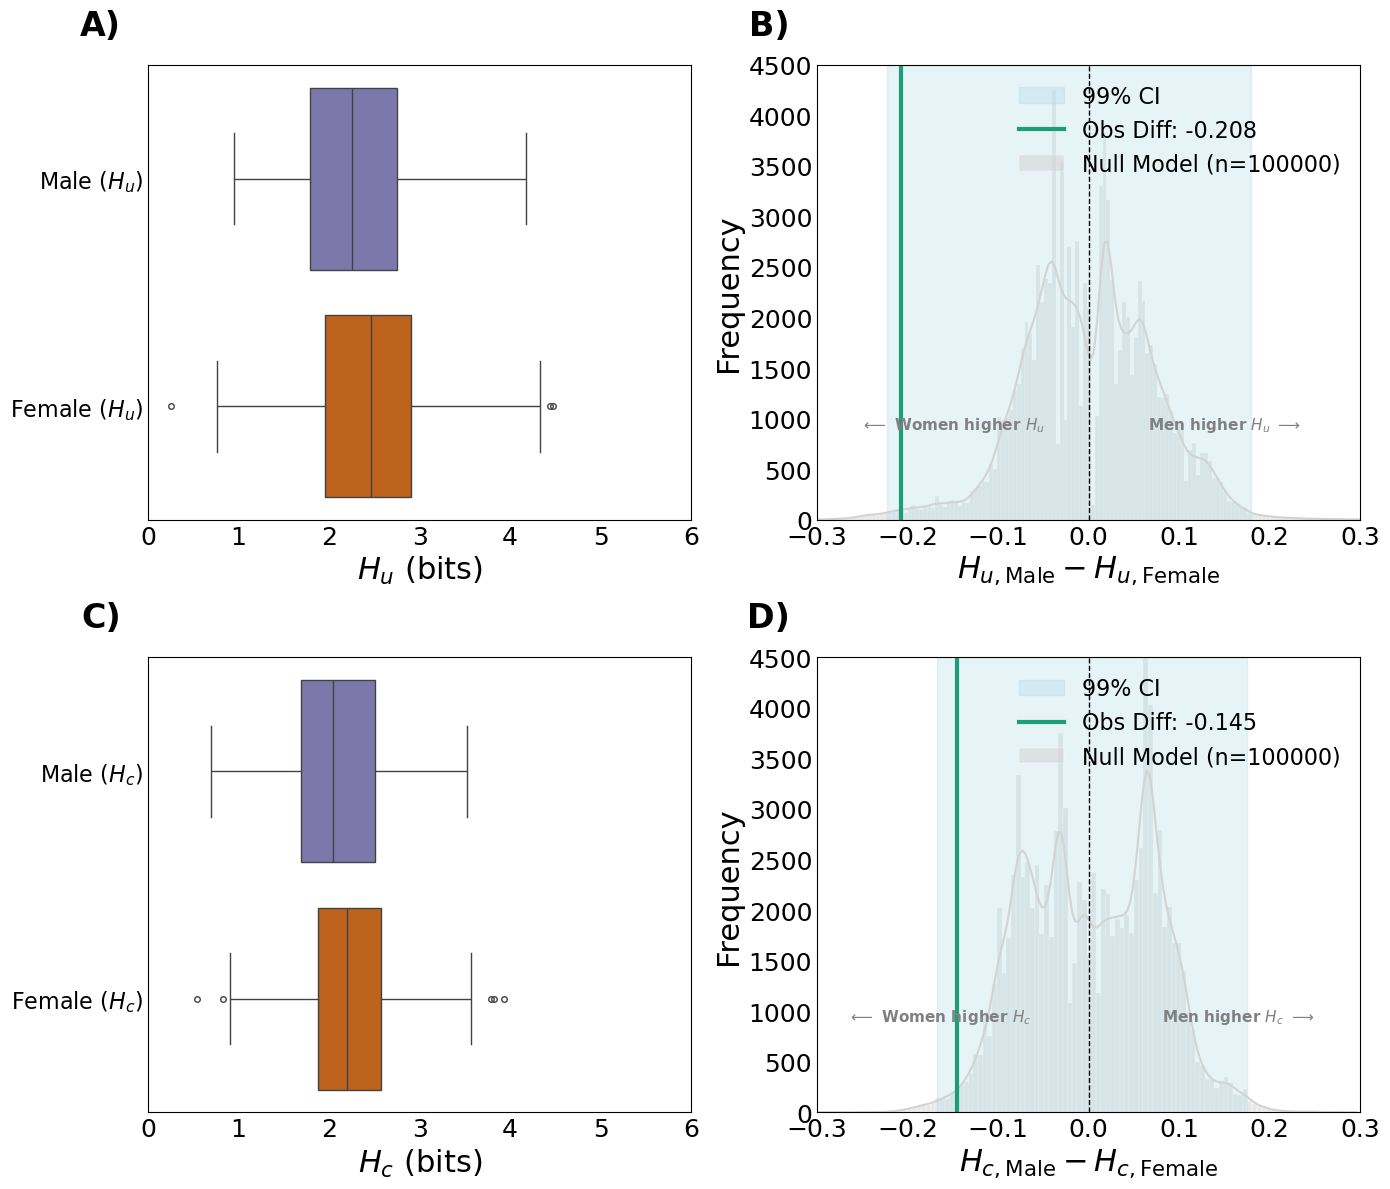

In [ ]:
cmap = plt.get_cmap('Dark2')
colors = [cmap(i) for i in [1, 2]]

fig, axs = plt.subplots(2, 2, figsize=(14, 12), gridspec_kw={'width_ratios': [7, 7]})
label_opts = dict(x=-0.05, y=1.05, fontsize=24, fontweight='bold', va='bottom', ha='right')

df_hu = pd.DataFrame({'Value': np.concatenate([hu_male, hu_female]),'Group': ['Male ($H_u$)'] * len(hu_male) + ['Female ($H_u$)'] * len(hu_female)})
sns.boxplot(data=df_hu, x='Value', y='Group', palette=[colors[1], colors[0]], ax=axs[0, 0], fliersize=4)
axs[0, 0].set_xlabel('$H_u$ (bits)', fontsize=22)
axs[0, 0].set_ylabel('', fontsize=22)
axs[0, 0].tick_params(axis='x', direction='in', length=0, labelsize=18)
axs[0, 0].tick_params(axis='y', labelsize=16, length=0)
axs[0, 0].set_xlim(0, 6)
axs[0, 0].text(transform=axs[0, 0].transAxes, s="A)", **label_opts)

df_hc = pd.DataFrame({'Value': np.concatenate([hc_male, hc_female]),'Group': ['Male ($H_c$)'] * len(hc_male) + ['Female ($H_c$)'] * len(hc_female)})
sns.boxplot(data=df_hc, x='Value', y='Group', palette=[colors[1], colors[0]], ax=axs[1, 0], fliersize=4)
axs[1, 0].set_xlabel('$H_c$ (bits)', fontsize=22)
axs[1, 0].set_ylabel('', fontsize=22)
axs[1, 0].tick_params(axis='x', direction='in', length=0, labelsize=18)
axs[1, 0].tick_params(axis='y', labelsize=16, length=0)
axs[1, 0].set_xlim(0, 6)
axs[1, 0].text(transform=axs[1, 0].transAxes, s="C)", **label_opts)

total_iterations = len(null_diffs_hu)
frames_list = [1, 2, 5, 10, 20, 50] + list(range(100, total_iterations + 1, 100))
if total_iterations not in frames_list:
    frames_list.append(total_iterations)

def update(frame_idx):
    axs[0, 1].cla()
    axs[1, 1].cla()
    current_n = frames_list[frame_idx]
    current_hu = null_diffs_hu[:current_n]
    current_hc = null_diffs_hc[:current_n]
    
    if current_n > 1:
        sns.histplot(current_hu, kde=True, color='lightgray', edgecolor='white', label=f'Null Model (n={current_n})', ax=axs[0, 1])
        sns.histplot(current_hc, kde=True, color='lightgray', edgecolor='white', label=f'Null Model (n={current_n})', ax=axs[1, 1])
    else:
        axs[0, 1].plot(current_hu, [1], 'o', color='lightgray', label=f'Null Model (n={current_n})')
        axs[1, 1].plot(current_hc, [1], 'o', color='lightgray', label=f'Null Model (n={current_n})')
    
    if current_n >= 40:
        ci_low_hu = np.percentile(current_hu, 0.5)
        ci_high_hu = np.percentile(current_hu, 99.5)
        axs[0, 1].axvspan(ci_low_hu, ci_high_hu, color='lightblue', alpha=0.3, label='99% CI')
        
        ci_low_hc = np.percentile(current_hc, 0.5)
        ci_high_hc = np.percentile(current_hc, 99.5)
        axs[1, 1].axvspan(ci_low_hc, ci_high_hc, color='lightblue', alpha=0.3, label='99% CI')
        
    axs[0, 1].axvline(obs_diff_hu, color=cmap(0), lw=3, label=f'Obs Diff: {obs_diff_hu:.3f}')
    axs[0, 1].axvline(0, color='black', lw=1, linestyle='--')
    axs[0, 1].set_xlim(-0.3, 0.3)
    axs[0, 1].set_ylim(0, 4500)
    axs[0, 1].set_xlabel(r'$H_{u, \mathrm{Male}} - H_{u, \mathrm{Female}}$', fontsize=22)
    axs[0, 1].set_ylabel('Frequency', fontsize=22)
    axs[0, 1].tick_params(axis='both', direction='in', length=0, labelsize=18)
    axs[0, 1].legend(frameon=False, fontsize=16, loc='upper right')
    axs[0, 1].text(transform=axs[0, 1].transAxes, s="B)", **label_opts)
    
    axs[0, 1].text(-0.3*0.5, 4500*0.2, '$\longleftarrow$ Women higher $H_u$', color='gray', fontweight='bold', ha='center', fontsize=11)
    axs[0, 1].text(0.3*0.5, 4500*0.2, 'Men higher $H_u$ $\longrightarrow$', color='gray', fontweight='bold', ha='center', fontsize=11)

    axs[1, 1].axvline(obs_diff_hc, color=cmap(0), lw=3, label=f'Obs Diff: {obs_diff_hc:.3f}')
    axs[1, 1].axvline(0, color='black', lw=1, linestyle='--')
    axs[1, 1].set_xlim(-0.3, 0.3)
    axs[1, 1].set_ylim(0, 4500)
    axs[1, 1].set_xlabel(r'$H_{c, \mathrm{Male}} - H_{c, \mathrm{Female}}$', fontsize=22)
    axs[1, 1].set_ylabel('Frequency', fontsize=22)
    axs[1, 1].tick_params(axis='both', direction='in', length=0, labelsize=18)
    axs[1, 1].legend(frameon=False, loc='upper right', fontsize=16)
    axs[1, 1].text(transform=axs[1, 1].transAxes, s="D)", **label_opts)
    
    axs[1, 1].text(-0.3*0.55, 4500*0.2, '$\longleftarrow$ Women higher $H_c$', color='gray', fontweight='bold', ha='center', fontsize=11)
    axs[1, 1].text(0.3*0.55, 4500*0.2, 'Men higher $H_c$ $\longrightarrow$', color='gray', fontweight='bold', ha='center', fontsize=11)
    
    plt.tight_layout()

ani = FuncAnimation(fig, update, frames=len(frames_list), repeat=True)
ani.save('panel_entropy_analysis.gif', writer='pillow', fps=10, dpi=150)
plt.show()

GOOD!! order of pois has no effect on H_U since it is UNCORRELATED!! it does not account for the sequence of locations.
H_C

pvalue: 6.763727136854743e-77


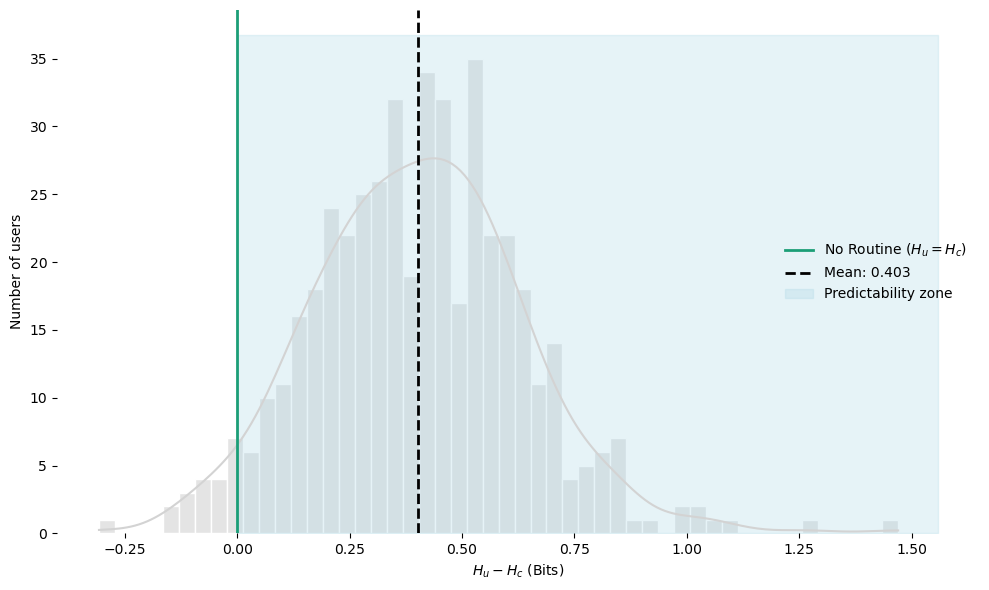

In [ ]:
user_stats['diff'] = user_stats['Hu'] - user_stats['Hc']
stat, p_val = wilcoxon(user_stats['Hu'], user_stats['Hc'], alternative='greater')
print(f"pvalue:",p_val)
cmap = plt.get_cmap('Dark2')
plt.figure(figsize=(10, 6))
sns.histplot(user_stats['diff'], bins=50, kde=True, color='lightgray', edgecolor='white', alpha=0.6)
plt.axvline(0, color=cmap(0), linestyle='-', lw=2, label='No Routine ($H_u = H_c$)')
plt.axvline(user_stats['diff'].mean(), color='black', linestyle='--', lw=2, label=f'Mean: {user_stats["diff"].mean():.3f}')
plt.fill_betweenx(y=[0, plt.gca().get_ylim()[1]], x1=0, x2=plt.gca().get_xlim()[1], color='lightblue', alpha=0.3, label='Predictability zone')

#plt.text(user_stats['diff'].mean()*1.1, plt.gca().get_ylim()[1]*0.8, f'p-value: {p_val:.2e}\n(Altamente significativo)', bbox=dict(facecolor='white', alpha=0.5))
plt.xlabel('$H_u - H_c$ (Bits)')
plt.ylabel('Number of users')
plt.legend(frameon=False)

for ax in plt.gcf().axes:
    for spine in ax.spines.values():
        spine.set_visible(False)

plt.tight_layout()
#plt.savefig('figs/hu-hc.png', dpi=300)
plt.show()

In [ ]:
entropy_comparison = pd.DataFrame({'Hu': hu_values, 'Hc': results_hc}).dropna()
user_stats = pd.DataFrame({'Hu': to_clean_series(hu_values),'Hc': to_clean_series(results_hc)}).dropna()
user_stats['diff'] = user_stats['Hu'] - user_stats['Hc']
stat, p_val = wilcoxon(user_stats['Hu'], user_stats['Hc'], alternative='greater')
print(f"p-value (Wilcoxon Hu > Hc): {p_val}")

fig, axs = plt.subplots(1, 2, figsize=(16, 6))
cmap = plt.get_cmap('Dark2')
sns.kdeplot(entropy_comparison['Hu'], fill=True, color='lightblue', label='$H_u$ (Uncorrelated)', alpha=0.5, ax=axs[0])
axs[0].axvline(entropy_comparison['Hu'].median(), color='lightblue', linestyle='--', linewidth=1.5, label=f"$H_u$ Median: {entropy_comparison['Hu'].median():.2f}")
sns.kdeplot(entropy_comparison['Hc'], fill=True, color='#3b5998', label='$H_c$ (Correlated)', alpha=0.6, ax=axs[0])
axs[0].axvline(entropy_comparison['Hc'].median(), color='#3b5998', linestyle='--', linewidth=1.5, label=f"$H_c$ Median: {entropy_comparison['Hc'].median():.2f}")
axs[0].set_xlabel('H (bits)', fontsize=12)
axs[0].set_ylabel('$p(H)$', fontsize=12)
axs[0].set_xlim(0, 6) 
axs[0].legend(frameon=False, fontsize=10, loc='upper right')
axs[0].tick_params(axis='both', length=0)

sns.histplot(user_stats['diff'], bins=50, kde=True, color='lightgray', edgecolor='white', alpha=0.6, ax=axs[1])
axs[1].axvline(0, color=cmap(0), linestyle='-', lw=2, label='No Routine ($H_u = H_c$)')
axs[1].axvline(user_stats['diff'].mean(), color='black', linestyle='--', lw=2, label=f'Mean: {user_stats["diff"].mean():.3f}')
y_max_1 = axs[1].get_ylim()[1]
x_max_1 = axs[1].get_xlim()[1]
axs[1].fill_betweenx(y=[0, y_max_1], x1=0, x2=x_max_1, color='lightblue', alpha=0.3, label='Predictability zone')
axs[1].set_xlabel('$H_u - H_c$ (Bits)', fontsize=12)
axs[1].set_ylabel('Number of users', fontsize=12)
axs[1].set_ylim(0, y_max_1) 
axs[1].legend(frameon=False, fontsize=10, loc='upper right')
axs[1].tick_params(axis='both', length=0)

for ax in axs:
    for spine in ax.spines.values():
        spine.set_visible(False)

plt.tight_layout()
#plt.savefig('figs/entropy_and_diff_panel.png', dpi=300, bbox_inches='tight')
plt.show()

NameError: name 'results_hc' is not defined

In [32]:
results = []
for uid, group in checkins.groupby('user_id'):
    seq = list(group['POI_id'])
    n = len(seq)
    unique_pois = len(set(seq))
    repeat_rate = (n - unique_pois) / n
    results.append(repeat_rate)

print(f"Repetitividad media: {np.mean(results):.2f}")

diff_to_max = comparison_df['Hu_orig'].mean() - comparison_df['Hc_orig'].mean()
print(f"Brecha de predictibilidad (Hu - Hc): {diff_to_max:.4f}")

Repetitividad media: 0.67


NameError: name 'comparison_df' is not defined

In [ ]:
rutina_extrema = ['A', 'B'] * 25 
caos_puro = np.random.choice(['A', 'B', 'C', 'D'], size=50).tolist()

def test_hc(name, seq):
    h_orig = compute_hc(seq)
    shuffled = np.random.permutation(seq).tolist()
    h_shuff = compute_hc(shuffled)
    
    print(f"--- {name} ---")
    print(f"Original Hc: {h_orig:.4f}")
    print(f"Shuffled Hc: {h_shuff:.4f}")
    print(f"Incremento: {h_shuff - h_orig:.4f}\n")

test_hc("USUARIO RUTINARIO (A-B-A-B)", rutina_extrema)
test_hc("USUARIO CAÓTICO", caos_puro)

--- USUARIO RUTINARIO (A-B-A-B) ---
Original Hc: 0.2302
Shuffled Hc: 1.0649
Incremento: 0.8347

--- USUARIO CAÓTICO ---
Original Hc: 1.8688
Shuffled Hc: 1.9462
Incremento: 0.0773



In [ ]:
uid = checkins['user_id'].unique()[0]
orig = checkins[checkins['user_id'] == uid]['POI_id'].tolist()
shuf = checkins_shuffled[checkins_shuffled['user_id'] == uid]['POI_id'].tolist()

print(f"Usuario {uid} - Primeros 10 POIs:")
print(f"Original: {orig[:10]}")
print(f"Shuffled: {shuf[:10]}")
print(f"¿Son iguales?: {orig == shuf}")

Usuario 1 - Primeros 10 POIs:
Original: ['5490185227910716682', '17214512960828070221', '4729662251588710116', '6871601350206860172', '6655511870058958765', '17214512960828070221', '7851260396140490874', '14045516142502963848', '7851260396140490874', '17214512960828070221']
Shuffled: ['17214512960828070221', '16266402063856124843', '14045516142502963848', '17214512960828070221', '4729662251588710116', '17214512960828070221', '7851260396140490874', '7851260396140490874', '17214512960828070221', '16998059090502984996']
¿Son iguales?: False


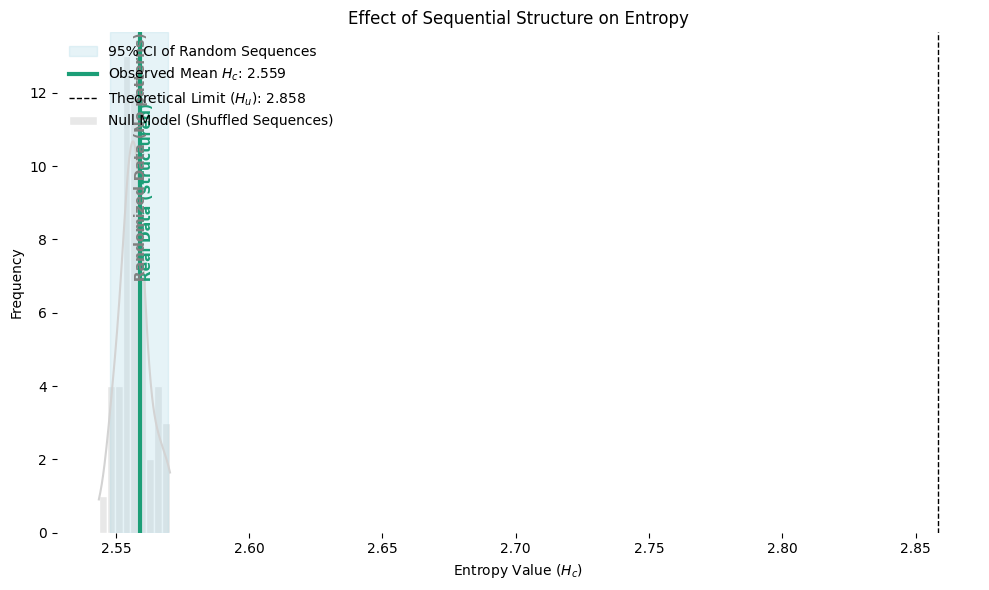

In [ ]:
def find_shortest_new_sequence(sequence, i):
    n = len(sequence)
    for length in range(1, n - i + 1):
        sub_sequence = sequence[i:i + length]
        is_seen = False
        for j in range(i):
            if sequence[j:j + length] == sub_sequence:
                is_seen = True
                break
        if not is_seen:
            return length
    return n - i + 1

def compute_hc(sequence):
    n = len(sequence)
    if n < 2:
        return np.nan
    total_lambda = 0
    for i in range(n):
        total_lambda += find_shortest_new_sequence(sequence, i)
    return (n * np.log2(n)) / total_lambda

def compute_hu(seq):
    if len(seq) == 0: return 0
    probs = pd.Series(seq).value_counts(normalize=True)
    return -np.sum(probs * np.log2(probs))

checkins = checkins.sort_values(by=['user_id', 'day', 'time'])

original_stats = checkins.groupby('user_id').agg({
    'POI_id': [lambda x: compute_hu(list(x)), lambda x: compute_hc(list(x))]
})
original_stats.columns = ['Hu', 'Hc']
obs_mean_hc = original_stats['Hc'].mean()
obs_mean_hu = original_stats['Hu'].mean()

null_means_hc = []
n_iterations = 50 

for _ in range(n_iterations):
    shuffled_df = checkins.copy()
    shuffled_df['POI_id'] = shuffled_df.groupby('user_id')['POI_id'].transform(np.random.permutation)
    
    current_hc_mean = shuffled_df.groupby('user_id')['POI_id'].apply(lambda x: compute_hc(list(x))).mean()
    null_means_hc.append(current_hc_mean)

null_means_hc = np.array(null_means_hc)
ci_low = np.percentile(null_means_hc, 2.5)
ci_high = np.percentile(null_means_hc, 97.5)

cmap = plt.get_cmap('Dark2')
plt.figure(figsize=(10, 6))

sns.histplot(null_means_hc, kde=True, color='lightgray', edgecolor='white', label='Null Model (Shuffled Sequences)')
plt.axvspan(ci_low, ci_high, color='lightblue', alpha=0.3, label='95% CI of Random Sequences')
plt.axvline(obs_mean_hc, color=cmap(0), lw=3, label=f'Observed Mean $H_c$: {obs_mean_hc:.3f}')
plt.axvline(obs_mean_hu, color='black', lw=1, linestyle='--', label=f'Theoretical Limit ($H_u$): {obs_mean_hu:.3f}')

y_max = plt.gca().get_ylim()[1]
plt.text(obs_mean_hc, y_max*0.5, ' Real Data (Structured)', rotation=90, color=cmap(0), fontweight='bold')
plt.text(null_means_hc.mean(), y_max*0.5, ' Randomized Data (No patterns)', rotation=90, color='gray', fontweight='bold')

plt.xlabel('Entropy Value ($H_c$)')
plt.ylabel('Frequency')
plt.title('Effect of Sequential Structure on Entropy')
plt.legend(frameon=False, loc='upper left')

for spine in plt.gca().spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.savefig('figs/sequence_impact_hc.png')
plt.show()

In [ ]:
def calculate_rg_metrics(df_user, k_value=2):
    loc_counts = df_user.groupby(['latitude', 'longitude']).size().reset_index(name='n_i')
    loc_counts = loc_counts.sort_values(by='n_i', ascending=False).reset_index(drop=True)
    def get_rg(df_subset):
        if df_subset.empty: return 0.0
        N = df_subset['n_i'].sum()
        r_cm_lat = (df_subset['latitude'] * df_subset['n_i']).sum() / N
        r_cm_lon = (df_subset['longitude'] * df_subset['n_i']).sum() / N
        dx = (df_subset['latitude'] - r_cm_lat) * 111
        dy = (df_subset['longitude'] - r_cm_lon) * 111 * np.cos(np.radians(r_cm_lat))
        sq_dist = dx**2 + dy**2
        return np.sqrt((df_subset['n_i'] * sq_dist).sum() / N)
    rg_total = get_rg(loc_counts)
    rg_k = get_rg(loc_counts.head(k_value))
    s_k = rg_k / rg_total if rg_total > 0 else 0
    profile = 'returner' if s_k > 0.5 else 'explorer'
    return pd.Series({
        'rg_total': rg_total,
        'rg_k': rg_k,'s_k': s_k, 'profile': profile})

k = 2 
resultados = checkins.groupby(['user_id', 'gender']).apply(calculate_rg_metrics, k_value=k).reset_index()
print(resultados.groupby(['gender', 'profile']).size())

gender  profile 
0       explorer    107
        returner     65
1       explorer    186
        returner    109
dtype: int64


C:\Users\34633\AppData\Local\Temp\ipykernel_30276\2046466695.py:25: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  resultados = checkins.groupby(['user_id', 'gender']).apply(calculate_rg_metrics, k_value=k).reset_index()


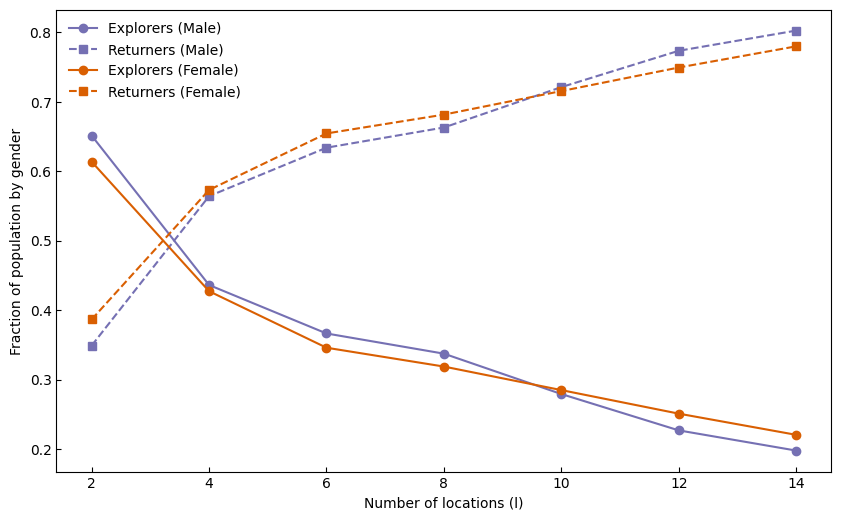

In [ ]:
def get_user_profiles(df, k_list):
    results = []
    for (user_id, gender), group in df.groupby(['user_id', 'gender']):
        loc_counts = group.groupby(['latitude', 'longitude']).size().reset_index(name='n_i')
        loc_counts = loc_counts.sort_values(by='n_i', ascending=False).reset_index(drop=True)
        def calculate_rg(data):
            if data.empty: return 0.0
            N = data['n_i'].sum()
            r_cm_lat = (data['latitude'] * data['n_i']).sum() / N
            r_cm_lon = (data['longitude'] * data['n_i']).sum() / N
            dx = (data['latitude'] - r_cm_lat) * 111
            dy = (data['longitude'] - r_cm_lon) * 111 * np.cos(np.radians(r_cm_lat))
            return np.sqrt((data['n_i'] * (dx**2 + dy**2)).sum() / N)
        rg_total = calculate_rg(loc_counts)
        for k in k_list:
            rg_k = calculate_rg(loc_counts.head(k))
            s_k = rg_k / rg_total if rg_total > 0 else 0
            profile = 'returner' if s_k > 0.5 else 'explorer'
            results.append({'gender': gender, 'k': k, 'profile': profile})  
    return pd.DataFrame(results)

k_values = [2, 4, 6, 8, 10, 12, 14]
df_profiles = get_user_profiles(checkins, k_values)

summary = df_profiles.groupby(['k', 'gender', 'profile']).size().unstack(fill_value=0)
summary['fraction_explorer'] = summary['explorer'] / (summary['explorer'] + summary['returner'])
summary['fraction_returner'] = summary['returner'] / (summary['explorer'] + summary['returner'])

fig, ax = plt.subplots(figsize=(10, 6))

for gender in summary.index.get_level_values('gender').unique():
    data = summary.xs(gender, level='gender')
    
    color = cmap(1) if gender == 1 else cmap(2)
    label_suffix = "Female" if gender == 1 else "Male"
    
    ax.plot(data.index, data['fraction_explorer'], marker='o', linestyle='-', 
            color=color, label=f'Explorers ({label_suffix})')
    ax.plot(data.index, data['fraction_returner'], marker='s', linestyle='--', 
            color=color, label=f'Returners ({label_suffix})')

ax.set_xlabel('Number of locations (l)')
ax.set_ylabel('Fraction of population by gender')
plt.tick_params(axis='both', direction='in')
ax.legend(frameon=False)
ax.grid(False)
plt.savefig('explorers.png', bbox_inches='tight', dpi = 300)
plt.show()

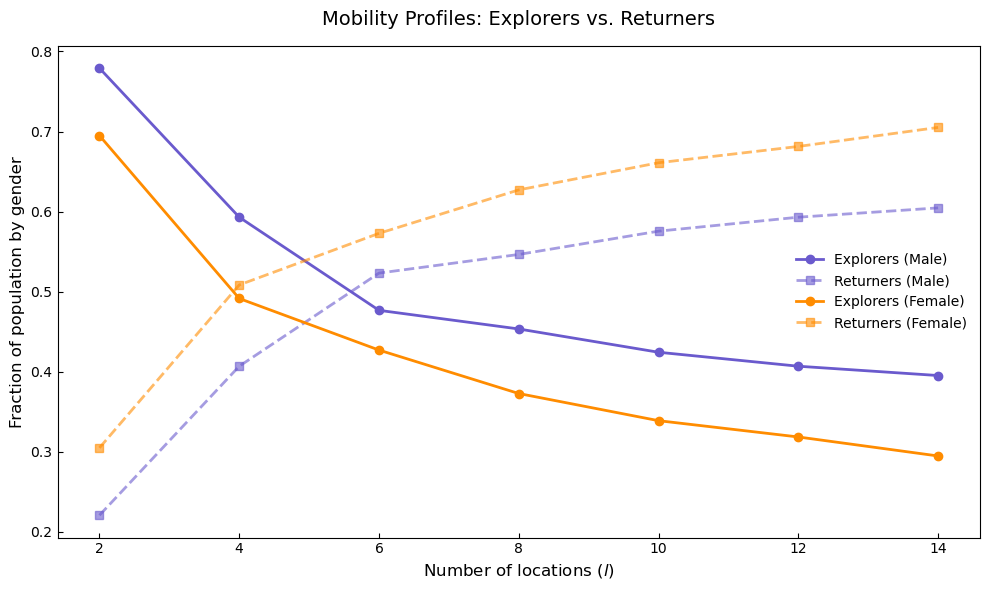

In [25]:
def get_user_profiles_consistent(df, k_list):
    results = []
    for (user_id, gender), group in df.groupby(['user_id', 'gender']):
        loc_counts = group.groupby(['latitude', 'longitude']).size().reset_index(name='n_i')
        loc_counts = loc_counts.sort_values(by='n_i', ascending=False).reset_index(drop=True)
        
        def calculate_rg(data):
            if data.empty: return 0.0
            N = data['n_i'].sum()
            r_cm_lat = (data['latitude'] * data['n_i']).sum() / N
            r_cm_lon = (data['longitude'] * data['n_i']).sum() / N
            dx = (data['latitude'] - r_cm_lat) * 111
            dy = (data['longitude'] - r_cm_lon) * 111 * np.cos(np.radians(r_cm_lat))
            return np.sqrt((data['n_i'] * (dx**2 + dy**2)).sum() / N)
        
        rg_total = calculate_rg(loc_counts)
        
        for k in k_list:
            rg_k = calculate_rg(loc_counts.head(k))
            s_k = rg_k / rg_total if rg_total > 0 else 0
            profile = 'returner' if s_k > 0.5 else 'explorer'
            results.append({'gender': gender, 'k': k, 'profile': profile})
            
    return pd.DataFrame(results)

k_values = [2, 4, 6, 8, 10, 12, 14]
df_profiles = get_user_profiles_consistent(checkins, k_values)
summary = df_profiles.groupby(['k', 'gender', 'profile']).size().unstack(fill_value=0)
summary['fraction_explorer'] = summary['explorer'] / (summary['explorer'] + summary['returner'])
summary['fraction_returner'] = summary['returner'] / (summary['explorer'] + summary['returner'])
fig, ax = plt.subplots(figsize=(10, 6))
palette_gender = {0: 'slateblue', 1: 'darkorange'}
labels_gen = {0: 'Male', 1: 'Female'}

for gender in [0, 1]:
    data = summary.xs(gender, level='gender')
    color = palette_gender[gender]
    ax.plot(data.index, data['fraction_explorer'], marker='o', linestyle='-', color=color, label=f'Explorers ({labels_gen[gender]})', linewidth=2)
    ax.plot(data.index, data['fraction_returner'], marker='s', linestyle='--', color=color, label=f'Returners ({labels_gen[gender]})', linewidth=2, alpha=0.6)
ax.set_xlabel('Number of locations ($l$)', fontsize=12)
ax.set_ylabel('Fraction of population by gender', fontsize=12)
ax.set_title('Mobility Profiles: Explorers vs. Returners', fontsize=14, pad=15)

plt.tick_params(axis='both', direction='in')
ax.legend(frameon=False, loc='best')
ax.grid(False)

plt.tight_layout()
#plt.savefig('explorers_returners_genero.png', dpi=300)
plt.show()

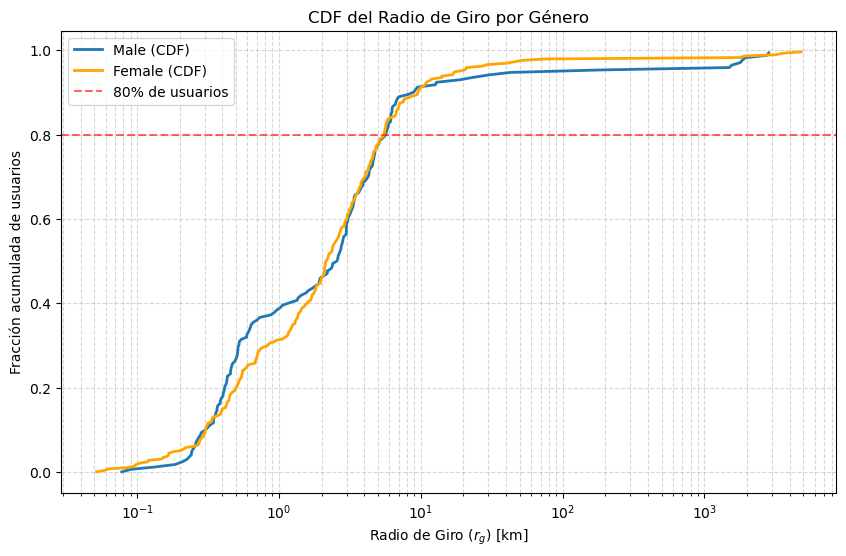

In [26]:
def get_user_rg(df):
    results = []
    for (user_id, gender), group in df.groupby(['user_id', 'gender']):
        loc_counts = group.groupby(['latitude', 'longitude']).size().reset_index(name='n_i')
        
        def calculate_rg(data):
            if data.empty: return 0.0
            N = data['n_i'].sum()
            r_cm_lat = (data['latitude'] * data['n_i']).sum() / N
            r_cm_lon = (data['longitude'] * data['n_i']).sum() / N
            dx = (data['latitude'] - r_cm_lat) * 111
            dy = (data['longitude'] - r_cm_lon) * 111 * np.cos(np.radians(r_cm_lat))
            return np.sqrt((data['n_i'] * (dx**2 + dy**2)).sum() / N)

        rg_total = calculate_rg(loc_counts)
        results.append({'gender': gender, 'rg_total': rg_total})
    return pd.DataFrame(results)

df_rg = get_user_rg(checkins)

fig, ax = plt.subplots(figsize=(10, 6))

for gender, color, label in [(0, 'tab:blue', 'Male'), (1, 'orange', 'Female')]:
    data = df_rg[df_rg['gender'] == gender]['rg_total'].sort_values()
    y_values = np.arange(len(data)) / float(len(data))
    ax.plot(data, y_values, label=f'{label} (CDF)', color=color, lw=2)

ax.axhline(0.8, color='red', linestyle='--', alpha=0.6, label='80% de usuarios')

ax.set_xscale('log')
ax.set_xlabel('Radio de Giro ($r_{g}$) [km]')
ax.set_ylabel('Fracción acumulada de usuarios')
ax.set_title('CDF del Radio de Giro por Género')
ax.legend()
ax.grid(True, which="both", linestyle='--', alpha=0.5)

plt.show()